In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    RocCurveDisplay,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True

In [ ]:
# Resolve dataset path from common locations
candidates = [
    Path("cinnamon_grading_dataset.csv"),
    Path("data/user-provided/cinnamon_grading_dataset.csv"),
    Path("/real_alba_c5.csv"),
]

dataset_path = next((p for p in candidates if p.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("Could not find grading dataset in expected locations.")

print("Using dataset:", dataset_path)
df_raw = pd.read_csv(dataset_path)
print("Shape:", df_raw.shape)
df_raw.head()

In [13]:
# Normalize schema names to API-compatible fields
rename_map = {
    "colour_value": "color_category",
    "texture_value": "texture_category",
}
df = df_raw.rename(columns=rename_map).copy()

if "grade" not in df.columns:
    if "grade_label" in df.columns:
        df["grade"] = df["grade_label"]
    else:
        raise ValueError("Dataset must include either 'grade' or 'grade_label'.")

required_features = ["diameter_mm", "color_category", "texture_category"]
missing = [c for c in required_features if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

X = df[required_features].copy()
y = df["grade"].astype(str)

# Basic cleanup
X["diameter_mm"] = pd.to_numeric(X["diameter_mm"], errors="coerce")
X = X.dropna(subset=["diameter_mm", "color_category", "texture_category"])
y = y.loc[X.index]

print("Features:", X.columns.tolist())
print("Classes:", sorted(y.unique().tolist()))
print("Samples:", len(X))

Features: ['diameter_mm', 'color_category', 'texture_category']
Classes: ['alba', 'c4', 'c5', 'c5_ex_sp', 'c5_sp']
Samples: 52


In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", ["diameter_mm"]),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            ["color_category", "texture_category"],
        ),
    ]
)

lr_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LogisticRegression(max_iter=5000)),
    ]
)

rf_model = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            min_samples_leaf=1,
        )),
    ]
)

lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Training complete.")

Training complete.


Logistic Regression Accuracy: 0.8182
Random Forest Accuracy:      1.0000

Random Forest Classification Report:
              precision    recall  f1-score   support

        alba       1.00      1.00      1.00         3
          c4       1.00      1.00      1.00         2
          c5       1.00      1.00      1.00         2
    c5_ex_sp       1.00      1.00      1.00         2
       c5_sp       1.00      1.00      1.00         2

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11



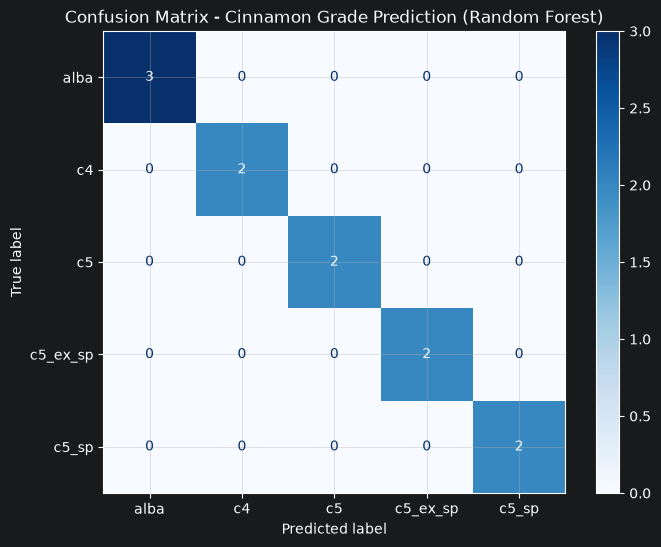

In [15]:
# Accuracy
lr_val_pred = lr_model.predict(X_val)
rf_val_pred = rf_model.predict(X_val)

lr_acc = accuracy_score(y_val, lr_val_pred)
rf_acc = accuracy_score(y_val, rf_val_pred)

print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"Random Forest Accuracy:      {rf_acc:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_val, rf_val_pred))

# Confusion matrix (Random Forest)
labels = sorted(y.unique().tolist())
cm = confusion_matrix(y_val, rf_val_pred, labels=labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(cmap="Blues")
plt.title("Confusion Matrix - Cinnamon Grade Prediction (Random Forest)")
plt.show()

Logistic Regression ROC-AUC (OvR): 0.9778
Random Forest ROC-AUC (OvR):      1.0000


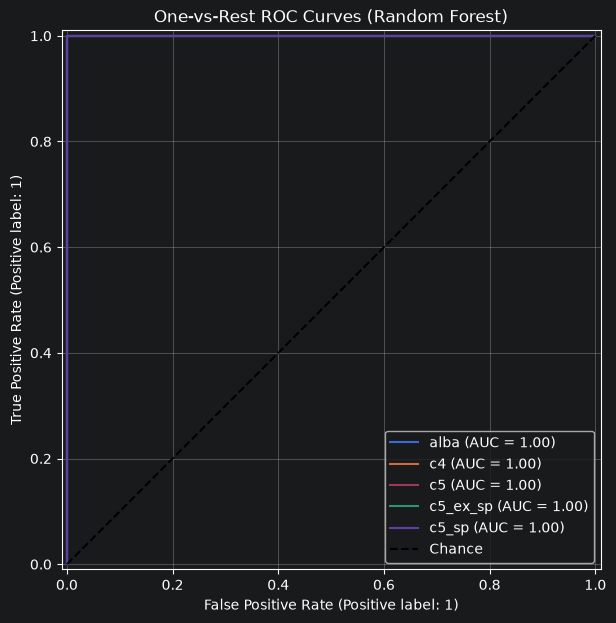

In [16]:
# ROC-AUC (multiclass OvR) and ROC curves
classes = np.array(sorted(y.unique().tolist()))
y_val_bin = label_binarize(y_val, classes=classes)

lr_val_prob = lr_model.predict_proba(X_val)
rf_val_prob = rf_model.predict_proba(X_val)

lr_auc = roc_auc_score(y_val_bin, lr_val_prob, multi_class="ovr", average="macro")
rf_auc = roc_auc_score(y_val_bin, rf_val_prob, multi_class="ovr", average="macro")

print(f"Logistic Regression ROC-AUC (OvR): {lr_auc:.4f}")
print(f"Random Forest ROC-AUC (OvR):      {rf_auc:.4f}")

fig, ax = plt.subplots(figsize=(9, 7))
for i, cls in enumerate(classes):
    RocCurveDisplay.from_predictions(
        y_val_bin[:, i],
        rf_val_prob[:, i],
        name=f"{cls}",
        ax=ax,
    )

plt.plot([0, 1], [0, 1], "k--", label="Chance")
plt.title("One-vs-Rest ROC Curves (Random Forest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [17]:
# Feature importance (Random Forest)
rf_inner = rf_model.named_steps["model"]
pre = rf_model.named_steps["preprocess"]
cat_names = pre.named_transformers_["cat"].get_feature_names_out(["color_category", "texture_category"])
all_feature_names = ["diameter_mm", *cat_names]

importance_df = pd.DataFrame(
    {
        "feature": all_feature_names,
        "importance": rf_inner.feature_importances_,
    }
).sort_values("importance", ascending=False)

importance_df.head(15)

,feature,importance
0,diameter_mm,0.688486
3,color_category_pale_golden_tan,0.083623
5,texture_category_immaculate,0.065321
1,color_category_deep_yellow_golden_brown,0.050186
8,texture_category_very_clean_under_15_percent_s...,0.038182
6,texture_category_moderately_patchy_40_to_60_pe...,0.021683
2,color_category_medium_brown_with_patches,0.020594
7,texture_category_rough_heavily_discoloured,0.016188
4,color_category_rough_dark_brown,0.015736


In [18]:
# Save best model artifact + evaluation report (API-compatible)
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

best_model = rf_model if rf_auc >= lr_auc else lr_model
best_name = "random_forest" if rf_auc >= lr_auc else "logistic_regression"
model_path = artifacts_dir / "grading_rf_track1.joblib"
joblib.dump(best_model, model_path)

report = {
    "track_1_real_data": {
        "track": "real_track_1",
        "model": best_name,
        "accuracy": round(float(max(rf_acc, lr_acc)), 6),
        "roc_auc_ovr_macro": round(float(max(rf_auc, lr_auc)), 6),
        "labels": classes.tolist(),
        "confusion_matrix": cm.tolist(),
    },
    "note": "This evaluation is for training/validation workflow only.",
}

report_path = artifacts_dir / "grading_evaluation_report.json"
with report_path.open("w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("Saved model:", model_path)
print("Saved report:", report_path)
report

Saved model: artifacts/grading_rf_track1.joblib
Saved report: artifacts/grading_evaluation_report.json


{'track_1_real_data': {'track': 'real_track_1',
  'model': 'random_forest',
  'accuracy': 1.0,
  'roc_auc_ovr_macro': 1.0,
  'labels': ['alba', 'c4', 'c5', 'c5_ex_sp', 'c5_sp'],
  'confusion_matrix': [[3, 0, 0, 0, 0],
   [0, 2, 0, 0, 0],
   [0, 0, 2, 0, 0],
   [0, 0, 0, 2, 0],
   [0, 0, 0, 0, 2]]},
 'note': 'This evaluation is for training/validation workflow only.'}

In [19]:
import joblib

joblib.dump(rf_model, "RandomCinnamon.pkl")

['RandomCinnamon.pkl']

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Assuming rf_val_pred contains your model's predictions and y_val contains the true labels
# For multiclass problems, choose an averaging method like 'macro' or 'weighted'

accuracy = accuracy_score(y_val, rf_val_pred)
precision = precision_score(y_val, rf_val_pred, average="macro", zero_division=0)
recall = recall_score(y_val, rf_val_pred, average="macro", zero_division=0)
f1 = f1_score(y_val, rf_val_pred, average="macro", zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")